# TP2 — Bin Packing : Heuristiques (Tests et résultats)

Equipe n°4 • Année universitaire : 2025-2026

---

Ce notebook présente une étude expérimentale des **heuristiques** pour le problème de Bin Packing : ranger un ensemble de $n$ objets, chacun de poids $w_i$, dans un nombre minimal de bins de capacité $C$.

Les heuristiques implémentées dans `2_heuristics/solver.py` sont :

- **Next Fit (NF)**
- **First Fit (FF)**
- **Best Fit (BF)**
- **Worst Fit (WF)**
- **Variantes "Decreasing"** : NFD, FFD, BFD, WFD
- **Heuristiques d'amélioration** : Relocation, Swap


---

## 1. Heuristiques de base

### 1.1 Next Fit (NF)

On maintient **un seul bin ouvert** : chaque objet est placé dans le bin courant s'il tient, sinon on **ouvre un nouveau bin**. Très rapide mais souvent peu efficace en nombre de bins.

### 1.2 First Fit (FF)

On scanne les bins dans l'ordre et on place l'objet dans **le premier bin** où il tient. C'est une heuristique simple et généralement plus efficace que NF.

### 1.3 Best Fit (BF) et Worst Fit (WF)

- **Best Fit (BF)** : placer l'objet dans le bin qui laissera **le moins d'espace libre**.
- **Worst Fit (WF)** : placer l'objet dans le bin qui laissera **le plus d'espace libre**.

BF tend à compacter les objets, WF garde des bins "larges" pour la suite.

### 1.4 Variantes "Decreasing" (NFD, FFD, BFD, WFD)

On **trie d'abord les objets par taille décroissante**, puis on applique NF, FF, BF ou WF. Cela améliore presque toujours la qualité des solutions, au prix d'un tri en $O(n \log n)$.

### 1.5 Qualité et complexité

- **NF** : $O(n)$, très rapide mais souvent plus de bins.
- **FF / BF / WF** : $O(n \cdot m)$, avec $m$ le nombre de bins (au pire $m \leq n$).
- **Variantes decreasing** : même coût + tri $O(n \log n)$.

La variante **FFD** possède une garantie classique :
$$\text{FFD} \leq \frac{11}{9} \, OPT + \frac{6}{9}$$


---

## 2. Heuristiques d'amélioration locales

### 2.1 Relocation

On part d'une solution **FFD**, puis on tente de **vider les bins légers** en déplaçant leurs objets vers d'autres bins. Si tous les objets d'un bin peuvent être relogés, le bin est supprimé.

### 2.2 Swap

On part d'une solution améliorée par relocation, puis on teste des **échanges d'objets entre bins**. Si un swap permet de réduire le nombre total de bins (souvent après une nouvelle phase de relocation), on l'accepte.

Ces heuristiques sont plus coûteuses, mais peuvent gagner 1 ou 2 bins sur des instances difficiles.


---

## 3. Mise en place


In [1]:
# ── Imports & path setup ─────────────────────────────────────────────────────
%matplotlib inline
import sys, time, random
from math import ceil
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

NOTEBOOK_DIR = Path('.').resolve()
if (NOTEBOOK_DIR / "solver.py").exists():
    SOLVER_DIR = NOTEBOOK_DIR
    PROJECT_ROOT = NOTEBOOK_DIR.parent
elif (NOTEBOOK_DIR / "2_heuristics" / "solver.py").exists():
    PROJECT_ROOT = NOTEBOOK_DIR
    SOLVER_DIR = NOTEBOOK_DIR / "2_heuristics"
else:
    raise FileNotFoundError("Impossible de localiser 2_heuristics/solver.py")

for path in [PROJECT_ROOT, SOLVER_DIR]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from solver import BinPackingSolver, BinPackingSolution

print("Imports OK — solver:", SOLVER_DIR, "| root:", PROJECT_ROOT)


Imports OK — solver: /home/amine/Documents/Projects/optimization/2_heuristics | root: /home/amine/Documents/Projects/optimization


---

## 4. Tests sur des instances simples

Nous validons les heuristiques sur quelques instances simples, puis on compare le nombre de bins utilisés avec la borne inférieure (LB).


In [2]:
# ── Helper : résoudre et afficher les résultats sur une instance ─────────────
def run_instance(sizes, capacity, label="Instance", methods=None):
    if methods is None:
        methods = [
            "nf",
            "ff",
            "bf",
            "wf",
            "nfd",
            "ffd",
            "bfd",
            "wfd",
            "relocation",
            "swap",
        ]

    lb = ceil(sum(sizes) / capacity)
    print(f"\n{'─'*70}")
    print(f"  {label}")
    print(f"  Objets (n={len(sizes)}) : {sizes}")
    print(f"  Capacité C = {capacity}  |  Somme = {sum(sizes)}  |  LB = {lb}")
    print(f"{'─'*70}")
    print(
        f"  {'Méthode':<18} {'Bins':>5} {'Gap':>5} {'Temps (s)':>12} {'Rempl.':>8}"
    )
    print(f"  {'─'*18} {'─'*5} {'─'*5} {'─'*12} {'─'*8}")

    results = {}
    for method in methods:
        try:
            solver = BinPackingSolver(sizes, capacity)
            t0 = time.perf_counter()
            solver.solve(method)
            elapsed = time.perf_counter() - t0
            sol = solver.get_solution()
            gap = sol.total_bins_used - lb
            fill = sum(sizes) / (sol.total_bins_used * capacity) * 100
            print(
                f"  {method:<18} {sol.total_bins_used:>5} {gap:>5} {elapsed:>12.6f} {fill:>7.1f}%"
            )
            results[method] = sol
        except Exception as e:
            print(f"  {method:<18} {'N/A':>5} {'N/A':>5} {'N/A':>12} {'N/A':>8}  {e}")

    return results


# ── Instance 1 : triviale ────────────────────────────────────────────────────
run_instance(
    sizes=[4, 3, 3, 2, 2, 1], capacity=5, label="Instance 1 — triviale (n=6, C=5)"
)

# ── Instance 2 : classique ───────────────────────────────────────────────────
run_instance(
    sizes=[10, 9, 6, 5, 5, 4, 4, 3, 3, 2],
    capacity=10,
    label="Instance 2 — classique (n=10, C=10)",
)

# ── Instance 3 : objets uniformes ────────────────────────────────────────────
run_instance(
    sizes=[6, 6, 6, 5, 5, 5, 4, 4, 4],
    capacity=11,
    label="Instance 3 — objets uniformes (n=9, C=11)",
)



──────────────────────────────────────────────────────────────────────
  Instance 1 — triviale (n=6, C=5)
  Objets (n=6) : [4, 3, 3, 2, 2, 1]
  Capacité C = 5  |  Somme = 15  |  LB = 3
──────────────────────────────────────────────────────────────────────
  Méthode             Bins   Gap    Temps (s)   Rempl.
  ────────────────── ───── ───── ──────────── ────────
  nf                     4     1     0.000104    75.0%
  ff                     3     0     0.000016   100.0%
  bf                     3     0     0.000016   100.0%
  wf                     3     0     0.000012   100.0%
  nfd                    4     1     0.000008    75.0%
  ffd                    3     0     0.000006   100.0%
  bfd                    3     0     0.000007   100.0%
  wfd                    3     0     0.000006   100.0%
  relocation             3     0     0.000021   100.0%
  swap                   3     0     0.000040   100.0%

──────────────────────────────────────────────────────────────────────
  Instance 

{'nf': BinPackingSolution(total_bins_used=6, bin_assignments={0: [0], 1: [1], 2: [2, 3], 3: [4, 5], 4: [6, 7], 5: [8]}, final_bin_loads=[6, 6, 11, 10, 8, 4]),
 'ff': BinPackingSolution(total_bins_used=5, bin_assignments={0: [0, 3], 1: [1, 4], 2: [2, 5], 3: [6, 7], 4: [8]}, final_bin_loads=[11, 11, 11, 8, 4]),
 'bf': BinPackingSolution(total_bins_used=5, bin_assignments={0: [0, 3], 1: [1, 4], 2: [2, 5], 3: [6, 7], 4: [8]}, final_bin_loads=[11, 11, 11, 8, 4]),
 'wf': BinPackingSolution(total_bins_used=5, bin_assignments={0: [0, 3], 1: [1, 4], 2: [2, 5], 3: [6, 7], 4: [8]}, final_bin_loads=[11, 11, 11, 8, 4]),
 'nfd': BinPackingSolution(total_bins_used=6, bin_assignments={0: [0], 1: [1], 2: [2, 3], 3: [4, 5], 4: [6, 7], 5: [8]}, final_bin_loads=[6, 6, 11, 10, 8, 4]),
 'ffd': BinPackingSolution(total_bins_used=5, bin_assignments={0: [0, 3], 1: [1, 4], 2: [2, 5], 3: [6, 7], 4: [8]}, final_bin_loads=[11, 11, 11, 8, 4]),
 'bfd': BinPackingSolution(total_bins_used=5, bin_assignments={0: [0, 3]

---

## 5. Visualisation des solutions

Pour une instance donnée, on visualise graphiquement l'affectation des objets dans les bins.


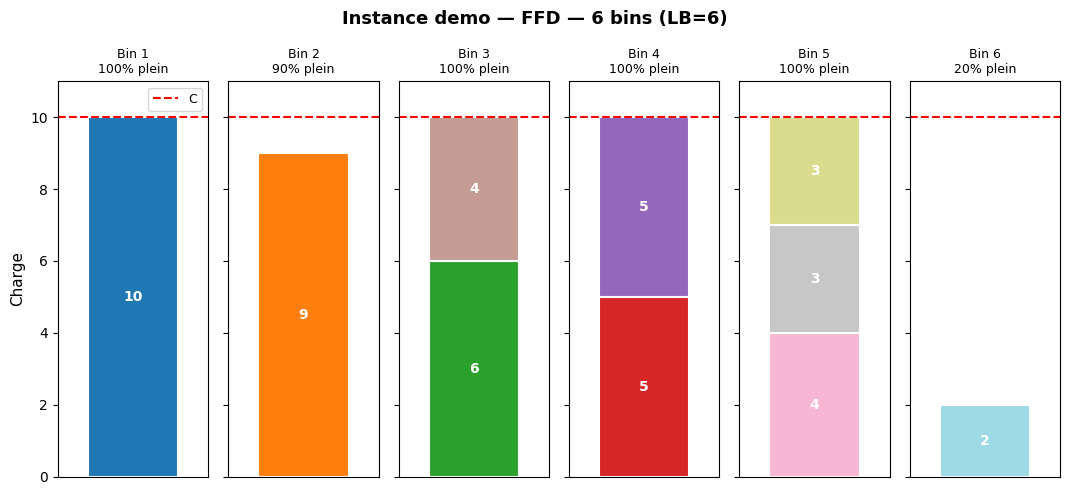

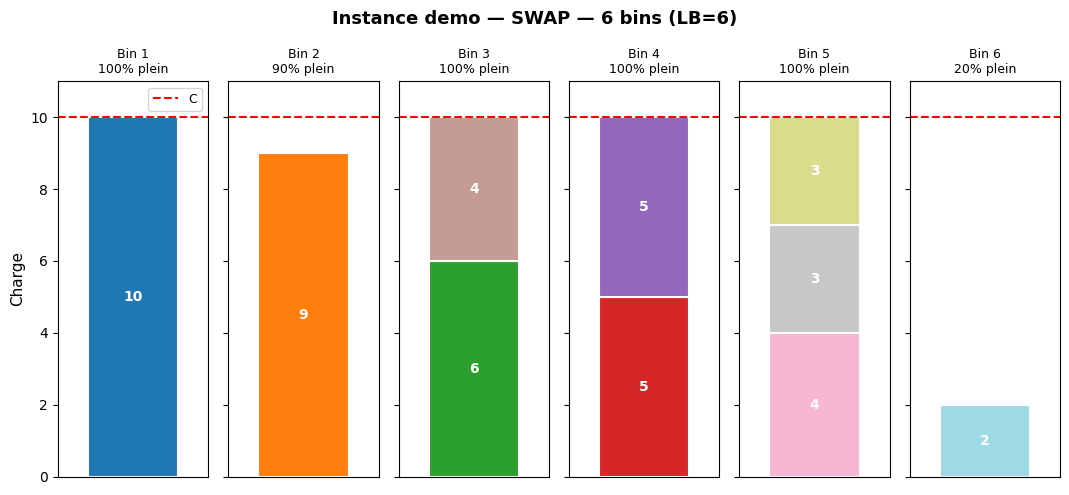

In [3]:
def plot_solution(sizes, capacity, solution: BinPackingSolution, title="Solution Bin Packing"):
    # Visualise l'affectation des objets dans les bins.
    n_bins = solution.total_bins_used
    cmap = plt.get_cmap("tab20", len(sizes))

    fig, axes = plt.subplots(1, n_bins, figsize=(max(8, n_bins * 1.8), 5), sharey=True)
    if n_bins == 1:
        axes = [axes]

    for bin_idx, ax in enumerate(axes):
        items = solution.bin_assignments.get(bin_idx, [])
        bottom = 0
        for item_idx in items:
            item_size = sizes[item_idx]
            ax.bar(
                0,
                item_size,
                bottom=bottom,
                width=0.6,
                color=cmap(item_idx),
                edgecolor="white",
                linewidth=1.5,
            )
            ax.text(
                0,
                bottom + item_size / 2,
                str(item_size),
                ha="center",
                va="center",
                fontsize=10,
                fontweight="bold",
                color="white",
            )
            bottom += item_size
        ax.axhline(
            capacity,
            color="red",
            linestyle="--",
            linewidth=1.5,
            label="C" if bin_idx == 0 else "",
        )
        fill = bottom / capacity * 100
        ax.set_title(f"Bin {bin_idx+1}\n{fill:.0f}% plein", fontsize=9)
        ax.set_ylim(0, capacity * 1.1)
        ax.set_xlim(-0.5, 0.5)
        ax.set_xticks([])
        if bin_idx == 0:
            ax.set_ylabel("Charge", fontsize=11)

    fig.suptitle(title, fontsize=13, fontweight="bold")
    axes[0].legend(fontsize=9)
    plt.tight_layout()
    plt.show()


# Visualisation sur une instance
sizes_demo = [10, 9, 6, 5, 5, 4, 4, 3, 3, 2]
capacity_demo = 10

for method in ["ffd", "swap"]:
    solver = BinPackingSolver(sizes_demo, capacity_demo)
    solver.solve(method)
    sol = solver.get_solution()
    plot_solution(
        sizes_demo,
        capacity_demo,
        sol,
        title=f"Instance demo — {method.upper()} — {sol.total_bins_used} bins (LB={ceil(sum(sizes_demo)/capacity_demo)})",
    )


---

## 6. Comparaison des heuristiques — Qualité vs Taille

On compare plusieurs heuristiques sur des instances générées aléatoirement de taille croissante.


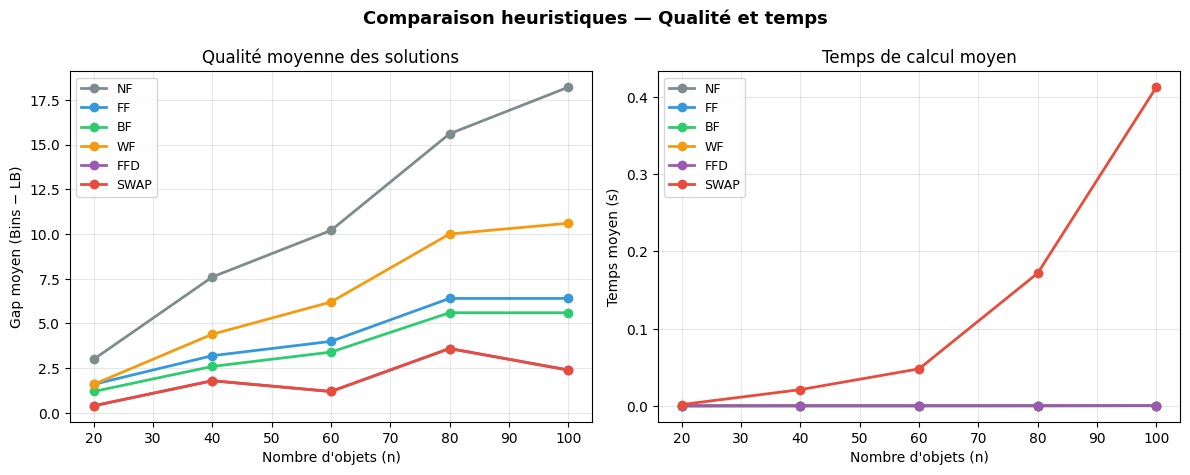

In [4]:
random.seed(42)
CAPACITY = 100
sizes_range = (20, 80)
N_VALUES = [20, 40, 60, 80, 100]
N_REPEAT = 5  # instances par taille

methods = ["nf", "ff", "bf", "wf", "ffd", "swap"]
colors = {
    "nf": "#7f8c8d",
    "ff": "#3498db",
    "bf": "#2ecc71",
    "wf": "#f39c12",
    "ffd": "#9b59b6",
    "swap": "#e74c3c",
}

metrics = {m: {n: {"gaps": [], "times": []} for n in N_VALUES} for m in methods}

for n in N_VALUES:
    for _ in range(N_REPEAT):
        sizes = [random.randint(*sizes_range) for _ in range(n)]
        lb = ceil(sum(sizes) / CAPACITY)
        for method in methods:
            solver = BinPackingSolver(sizes, CAPACITY)
            t0 = time.perf_counter()
            solver.solve(method)
            elapsed = time.perf_counter() - t0
            sol = solver.get_solution()
            metrics[method][n]["gaps"].append(sol.total_bins_used - lb)
            metrics[method][n]["times"].append(elapsed)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# Gap moyen vs taille
for method in methods:
    avg_gaps = []
    valid_ns = []
    for n in N_VALUES:
        gaps = metrics[method][n]["gaps"]
        if gaps:
            avg_gaps.append(sum(gaps) / len(gaps))
            valid_ns.append(n)
    axes[0].plot(
        valid_ns,
        avg_gaps,
        marker="o",
        label=method.upper(),
        color=colors[method],
        linewidth=2,
    )

axes[0].set_xlabel("Nombre d'objets (n)")
axes[0].set_ylabel("Gap moyen (Bins − LB)")
axes[0].set_title("Qualité moyenne des solutions")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

# Temps moyen vs taille
for method in methods:
    avg_times = []
    valid_ns = []
    for n in N_VALUES:
        times = metrics[method][n]["times"]
        if times:
            avg_times.append(sum(times) / len(times))
            valid_ns.append(n)
    axes[1].plot(
        valid_ns,
        avg_times,
        marker="o",
        label=method.upper(),
        color=colors[method],
        linewidth=2,
    )

axes[1].set_xlabel("Nombre d'objets (n)")
axes[1].set_ylabel("Temps moyen (s)")
axes[1].set_title("Temps de calcul moyen")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

fig.suptitle("Comparaison heuristiques — Qualité et temps", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()


---

## 7. Benchmark sur les jeux de données standard

Nous utilisons le module `benchmark.py` pour comparer les heuristiques sur des instances **Falkenauer T**.

> Cette section requiert la présence des fichiers de benchmark dans `benchmarks/`.


In [5]:
from benchmark import Benchmark, DATASET_REGISTRY, BenchmarkResult
import pandas as pd

SOLVER_PATH = (PROJECT_ROOT / "2_heuristics" / "solver.py").resolve()
GRAPHS_DIR = (PROJECT_ROOT / "results" / "2_heuristics").resolve()


def results_to_df(results: list[BenchmarkResult]) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {
                "Instance": r.instance_name,
                "Items": r.num_items,
                "Capacity": r.bin_capacity,
                "LB": r.lower_bound,
                "Bins": r.bins_used,
                "Gap": r.bins_used - r.lower_bound,
                "Time (s)": round(r.elapsed_time, 4),
                "T.O.": r.timed_out,
            }
            for r in results
        ]
    )


def summarize_results(results: list[BenchmarkResult], method: str) -> dict:
    if not results:
        return {
            "Méthode": method,
            "Instances": 0,
            "Gap moyen": None,
            "Rempl. moyen": None,
            "Temps moyen": None,
            "Timeouts": None,
        }

    completed = [r for r in results if not r.timed_out]
    avg_gap = sum(r.bins_used - r.lower_bound for r in completed) / max(1, len(completed))
    avg_fill = (
        sum(r.total_weight / (r.bins_used * r.bin_capacity) for r in completed)
        / max(1, len(completed))
        * 100
    )
    avg_time = sum(r.elapsed_time for r in completed) / max(1, len(completed))
    timeouts = len(results) - len(completed)

    return {
        "Méthode": method.upper(),
        "Instances": len(results),
        "Gap moyen": round(avg_gap, 3),
        "Rempl. moyen": round(avg_fill, 1),
        "Temps moyen": round(avg_time, 4),
        "Timeouts": timeouts,
    }


ModuleNotFoundError: No module named 'pandas'

In [ ]:
DATASET_KEY = "falkenauer-t"
MAX_ITEMS = 60
METHODS_BENCH = ["nf", "ff", "bf", "wf", "ffd", "bfd", "wfd", "relocation", "swap"]

results_by_method = {}
summary_rows = []

for method in METHODS_BENCH:
    try:
        bench = Benchmark(
            DATASET_REGISTRY[DATASET_KEY],
            SOLVER_PATH,
            GRAPHS_DIR,
            time_limit=None,
        )
        bench.run(method=method, max_items=MAX_ITEMS, generate_graphs=False)
        results = bench.get_results()
        results_by_method[method] = results
        summary_rows.append(summarize_results(results, method))
    except FileNotFoundError as e:
        print(f"Dataset introuvable : {e}")
        break

summary_df = pd.DataFrame(summary_rows)
if not summary_df.empty:
    summary_df = summary_df.sort_values(by=["Gap moyen", "Temps moyen"], ascending=[True, True])
summary_df


---

## 8. Graphiques d'analyse

Les graphiques suivants illustrent la qualité et la vitesse d'une heuristique choisie (par défaut : SWAP si disponible, sinon FFD).


In [ ]:
def make_demo_results(seed=0, method="ffd"):
    # Génère des résultats synthétiques réalistes pour la démonstration.
    rng = random.Random(seed)
    demo = []
    for i in range(20):
        n = rng.choice([20, 40, 60, 80])
        cap = 100
        lb = rng.randint(max(5, n // 4), n // 3)
        gap = rng.choices([0, 0, 0, 1, 2], k=1)[0]
        bins = lb + gap
        t = rng.uniform(0.0005, 0.05) * (n / 20) ** 1.6
        demo.append(
            BenchmarkResult(
                instance_name=f"inst_{i+1:02d}",
                dataset_key="demo",
                num_items=n,
                bin_capacity=cap,
                bins_used=bins,
                lower_bound=lb,
                total_weight=lb * cap - rng.randint(0, cap // 5),
                elapsed_time=t,
                method=method,
                timed_out=False,
            )
        )
    return demo


# Utilise les vrais résultats si disponibles, sinon les données démo
if "results_by_method" in dir() and results_by_method.get("swap"):
    display_results = results_by_method["swap"]
    dataset_label = f"{DATASET_REGISTRY[DATASET_KEY].label} — SWAP"
elif "results_by_method" in dir() and results_by_method.get("ffd"):
    display_results = results_by_method["ffd"]
    dataset_label = f"{DATASET_REGISTRY[DATASET_KEY].label} — FFD"
else:
    display_results = make_demo_results()
    dataset_label = "Données de démonstration"

completed = [r for r in display_results if not r.timed_out]
print(f"Affichage des graphiques pour : {dataset_label} ({len(completed)} instances)")


In [ ]:
# ── Fig 1 : Temps de résolution par instance ────────────────────────────────
fig, ax = plt.subplots(figsize=(max(10, len(completed) * 0.65), 5))

times = [r.elapsed_time for r in completed]
max_t = max(times) if times else 0
colors = ["#e74c3c" if t == max_t else "#3498db" for t in times]

ax.bar(range(len(completed)), times, color=colors, edgecolor="white", linewidth=0.5)
ax.set_xticks(range(len(completed)))
ax.set_xticklabels(
    [r.instance_name for r in completed], rotation=45, ha="right", fontsize=7
)
ax.set_ylabel("Temps de résolution (s)", fontsize=12)
ax.set_title(
    f"Fig 1 — Temps de résolution par instance  —  {dataset_label}",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax.grid(axis="y", alpha=0.3)

if times:
    max_idx = times.index(max_t)
    ax.annotate(
        f"Max : {max_t:.4f}s",
        xy=(max_idx, max_t),
        xytext=(max_idx, max_t * 1.05),
        ha="center",
        fontsize=8,
        color="#c0392b",
        fontweight="bold",
    )

fig.tight_layout()
plt.show()


In [ ]:
# ── Fig 2 : Bins utilisés vs Borne inférieure ───────────────────────────────
fig, ax = plt.subplots(figsize=(max(10, len(completed) * 0.65), 5))

x = range(len(completed))
lb_vals = [r.lower_bound for r in completed]
gap_vals = [r.bins_used - r.lower_bound for r in completed]
n_opt = sum(1 for g in gap_vals if g == 0)

ax.bar(
    x,
    lb_vals,
    label="Borne inférieure (LB)",
    color="#2ecc71",
    alpha=0.85,
    edgecolor="white",
)
ax.bar(
    x,
    gap_vals,
    bottom=lb_vals,
    label="Gap (Bins − LB)",
    color="#e74c3c",
    alpha=0.85,
    edgecolor="white",
)

ax.set_xticks(list(x))
ax.set_xticklabels(
    [r.instance_name for r in completed], rotation=45, ha="right", fontsize=7
)
ax.set_ylabel("Bins", fontsize=12)
ax.set_title(
    f"Fig 2 — Bins utilisés vs Borne inférieure  —  {dataset_label}\n"
    f"Solutions optimales : {n_opt}/{len(completed)}",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()


In [ ]:
# ── Fig 3 : Taux de remplissage des bins ────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(10, len(completed) * 0.65), 5))

fill_rates = [r.total_weight / (r.bins_used * r.bin_capacity) * 100 for r in completed]
if fill_rates:
    cmap = matplotlib.colormaps["RdYlGn"]
    norm = matplotlib.colors.Normalize(min(fill_rates), 100)
    bar_colors = [cmap(norm(v)) for v in fill_rates]

    ax.bar(range(len(completed)), fill_rates, color=bar_colors, edgecolor="white")
    ax.axhline(100, color="black", linewidth=1.2, linestyle="--", label="100 %")
    ax.axhline(80, color="orange", linewidth=1.0, linestyle=":", label="Seuil 80 %")

    for i, rate in enumerate(fill_rates):
        ax.text(i, rate + 0.4, f"{rate:.1f}%", ha="center", va="bottom", fontsize=7)

    sm = matplotlib.cm.ScalarMappable(cmap=cmap, norm=norm)
    plt.colorbar(sm, ax=ax, label="Taux de remplissage (%)", pad=0.02)

ax.set_xticks(range(len(completed)))
ax.set_xticklabels(
    [r.instance_name for r in completed], rotation=45, ha="right", fontsize=7
)
ax.set_ylim(0, 115)
ax.set_ylabel("Taux de remplissage moyen (%)", fontsize=12)
ax.set_title(
    f"Fig 3 — Qualité de la solution : Taux de remplissage  —  {dataset_label}",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax.legend(fontsize=10)
fig.tight_layout()
plt.show()


In [ ]:
# ── Fig 4 : Distribution des temps par taille d'instance (Box plot) ─────────
size_groups: dict = {}
for r in completed:
    size_groups.setdefault(r.num_items, []).append(r.elapsed_time)

if len(size_groups) >= 2:
    fig, ax = plt.subplots(figsize=(8, 5))
    sorted_sizes = sorted(size_groups.keys())
    group_times = [size_groups[n] for n in sorted_sizes]
    labels = [str(n) for n in sorted_sizes]

    box = ax.boxplot(
        group_times,
        tick_labels=labels,
        patch_artist=True,
        medianprops=dict(color="black", linewidth=1.8),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
    )
    viridis = matplotlib.colormaps["viridis"]
    palette = [viridis(v) for v in np.linspace(0.2, 0.85, len(sorted_sizes))]
    for patch, color in zip(box["boxes"], palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    rng = np.random.default_rng(seed=0)
    for idx, times in enumerate(group_times):
        jitter = rng.uniform(-0.12, 0.12, size=len(times))
        ax.scatter(
            np.full(len(times), idx + 1) + jitter,
            times,
            s=28,
            zorder=3,
            edgecolors="white",
            linewidths=0.4,
            color=palette[idx],
        )

    ax.set_yscale("log")
    ax.set_xlabel("Nombre d'objets (n)", fontsize=12)
    ax.set_ylabel("Temps de résolution (s)  [échelle log]", fontsize=12)
    ax.set_title(
        f"Fig 4 — Distribution des temps par taille  —  {dataset_label}",
        fontsize=13,
        fontweight="bold",
        pad=12,
    )
    fig.tight_layout()
    plt.show()
else:
    print("Toutes les instances ont la même taille.")


---

## 9. Statistiques récapitulatives


In [ ]:
results_all = display_results
completed = [r for r in results_all if not r.timed_out]

n_opt = sum(1 for r in completed if r.bins_used == r.lower_bound)

timeout_n = len(results_all) - len(completed)

avg_gap = sum(r.bins_used - r.lower_bound for r in completed) / max(1, len(completed))
avg_fill = (
    sum(r.total_weight / (r.bins_used * r.bin_capacity) for r in completed)
    / max(1, len(completed))
    * 100
)

avg_time = sum(r.elapsed_time for r in completed) / max(1, len(completed))

total_time = sum(r.elapsed_time for r in results_all)

print("═" * 52)
print(f"  STATISTIQUES RÉCAPITULATIVES — {dataset_label}")
print("═" * 52)
print(f"  Instances traitées      : {len(results_all)}")
print(f"  Solutions optimales     : {n_opt}/{len(completed)}")
print(f"  Gap moyen               : {avg_gap:.3f} bins")
print(f"  Taux de remplissage moy : {avg_fill:.1f} %")
print(f"  Temps total             : {total_time:.4f} s")
print(f"  Temps moyen (complètes) : {avg_time:.4f} s")
if timeout_n:
    print(f"  Timeouts                : {timeout_n}")
print("═" * 52)


---

## 10. Conclusion

| Critère                       | NF            | FF / BF / WF     | Variantes decreasing      | Relocation / Swap |
| ----------------------------- | ------------- | ---------------- | ------------------------- | ----------------- |
| **Qualité**                   | Faible        | Moyenne          | Bonne à très bonne        | Souvent meilleure |
| **Temps**                     | Très rapide   | Rapide           | Rapide + tri              | Plus coûteux      |
| **Complexité pratique**       | $O(n)$        | $O(n \cdot m)$   | $O(n \log n + n \cdot m)$ | Plus élevée       |
| **Usage recommandé**          | Dépannage     | Bon compromis    | Meilleur compromis        | Qualité prioritaire |

**Points clés :**

- Les variantes **decreasing** (en particulier FFD/BFD) offrent en général le meilleur compromis qualité/temps.
- **Relocation** et **Swap** peuvent réduire le nombre de bins, mais ajoutent un surcoût.
- Pour des volumes très grands, **NF** reste imbattable en vitesse mais souvent moins bon en qualité.
